# TEKNOFEST 2026 - Exploratory Data Analysis

Bu notebook `Adsiz dokuman.pdf` faylındakı EDA tələblərinə əsasən hazırlanıb.
Məqsəd yalnız verilənləri dərindən anlamaqdır: model qurulmur, hiperparametr
müzakirəsi edilmir.

Notebook mərhələləri:

1. Data integrity və struktur yoxlamaları
2. AL, CAT, EK, AA feature qruplarının univariate analizi
3. Feature vs Label bivariate analizi
4. AL triplet strukturu, cross-correlation, PCA və leakage scan
5. MASTER və panel datasetlərinin müqayisəsi
6. ACMG evidence interpretation


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

DATA_DIR = Path("teknofest2026_artificialintelligenceinhealtcare-main")
OUT_DIR = Path("reports/eda_notebook_outputs")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## Helper Functions


In [2]:
def cols(df, prefix):
    return [c for c in df.columns if c.startswith(prefix)]


def auc_equivalent(x, y):
    valid = x.notna() & y.notna()
    x = pd.to_numeric(x[valid], errors="coerce")
    y = y[valid]
    valid = x.notna()
    x = x[valid]
    y = y[valid]
    pos = x[y == 1]
    neg = x[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return np.nan, np.nan, np.nan
    res = stats.mannwhitneyu(pos, neg, alternative="two-sided")
    auc = float(res.statistic / (len(pos) * len(neg)))
    rank_biserial = float(2 * auc - 1)
    directional_strength = abs(auc - 0.5) + 0.5
    return auc, float(res.pvalue), rank_biserial


def missingness_band(rate):
    pct = rate * 100
    if pct == 0:
        return "0%"
    if pct <= 25:
        return "1-25%"
    if pct <= 50:
        return "26-50%"
    if pct <= 75:
        return "51-75%"
    if pct < 100:
        return "76-99%"
    return "100%"


## Phase 1 - Data Integrity And Structure


In [3]:
files = {
    "MASTER": "YARISMA_TRAIN_MASTER.csv",
    "KANSER": "YARISMA_TRAIN_KANSER.csv",
    "PAH": "YARISMA_TRAIN_PAH.csv",
    "CFTR": "YARISMA_TRAIN_CFTR.csv",
}

data = {name: pd.read_csv(DATA_DIR / filename) for name, filename in files.items()}
master = data["MASTER"]
master_cols = list(master.columns)

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "schema_identical_to_master": list(df.columns) == master_cols,
        "duplicate_variant_id": int(df["Variant_ID"].duplicated().sum()),
        "pathogenic": int(df["Label"].sum()),
        "benign": int((df["Label"] == 0).sum()),
        "pathogenic_rate": float(df["Label"].mean()),
    })

schema_df = pd.DataFrame(schema_rows)
schema_df.to_csv(TABLE_DIR / "phase1_schema_class_balance.csv", index=False)
schema_df


,dataset,rows,columns,schema_identical_to_master,duplicate_variant_id,pathogenic,benign,pathogenic_rate
0,MASTER,2931,353,True,0,2149,782,0.733197
1,KANSER,388,353,True,0,268,120,0.690722
2,PAH,372,353,True,0,310,62,0.833333
3,CFTR,111,353,True,0,90,21,0.810811


In [4]:
master_ids = set(data["MASTER"]["Variant_ID"])
panel_names = ["KANSER", "PAH", "CFTR"]
panel_ids = set().union(*(set(data[name]["Variant_ID"]) for name in panel_names))

overlap_rows = []
for name in panel_names:
    df = data[name]
    ids = set(df["Variant_ID"])
    unique = df[~df["Variant_ID"].isin(master_ids)]
    shared = df[df["Variant_ID"].isin(master_ids)]
    overlap_rows.append({
        "panel": name,
        "master_overlap": len(master_ids & ids),
        "panel_unique": len(unique),
        "panel_unique_pathogenic_rate": float(unique["Label"].mean()),
        "panel_shared_pathogenic_rate": float(shared["Label"].mean()),
    })

master_only = master[master["Variant_ID"].isin(master_ids - panel_ids)]
master_shared = master[master["Variant_ID"].isin(master_ids & panel_ids)]
overlap_df = pd.DataFrame(overlap_rows)
overlap_df.to_csv(TABLE_DIR / "phase1_overlaps.csv", index=False)
display(overlap_df)
print(f"MASTER-only: n={len(master_only)}, pathogenic_rate={master_only['Label'].mean():.4f}")
print(f"MASTER-shared: n={len(master_shared)}, pathogenic_rate={master_shared['Label'].mean():.4f}")


,panel,master_overlap,panel_unique,panel_unique_pathogenic_rate,panel_shared_pathogenic_rate
0,KANSER,246,142,0.316901,0.906504
1,PAH,255,117,0.581197,0.949020
2,CFTR,77,34,0.500000,0.948052


MASTER-only: n=2353, pathogenic_rate=0.6847
MASTER-shared: n=578, pathogenic_rate=0.9308


In [5]:
constant_rows = []
for col in master.columns:
    nonnull = master[col].dropna()
    if nonnull.empty:
        top_rate = np.nan
        top_value = None
    else:
        vc = nonnull.value_counts(dropna=False)
        top_value = vc.index[0]
        top_rate = float(vc.iloc[0] / len(nonnull))
    if nonnull.nunique(dropna=False) <= 1 or top_rate > 0.99:
        constant_rows.append({
            "column": col,
            "n_nonnull": len(nonnull),
            "n_unique_nonnull": nonnull.nunique(dropna=False),
            "top_value": top_value,
            "top_value_rate_nonnull": top_rate,
        })

constants_df = pd.DataFrame(constant_rows)
constants_df.to_csv(TABLE_DIR / "phase1_constant_near_constant.csv", index=False)
constants_df.head(30)


,column,n_nonnull,n_unique_nonnull,top_value,top_value_rate_nonnull
0,AL_80,1197,1,1.0,1.0
1,AL_101,1486,1,1.0,1.0
2,AL_104,1486,1,1.0,1.0
3,AL_107,1486,1,1.0,1.0
4,AL_110,1486,1,1.0,1.0
5,AL_113,1486,1,1.0,1.0
6,AL_116,1486,1,1.0,1.0
7,AL_119,1486,1,1.0,1.0
8,AL_122,1486,1,1.0,1.0
9,AL_125,1486,1,1.0,1.0


,band,columns
0,26-50%,173
1,51-75%,146
2,76-99%,19
3,1-25%,13
4,0%,2


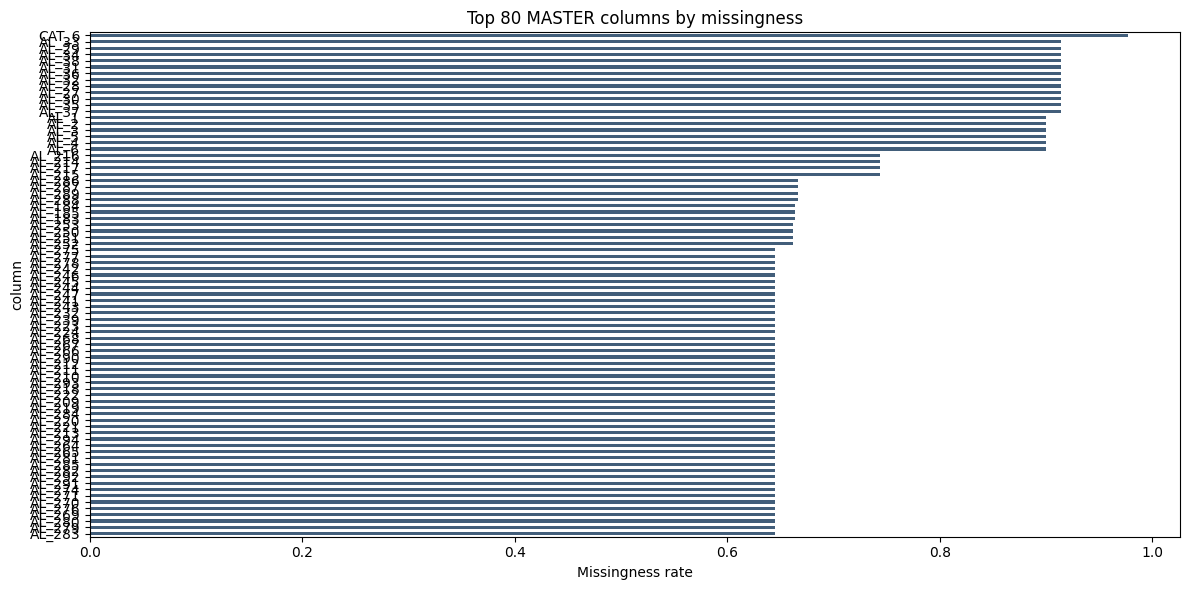

In [6]:
missing_df = pd.DataFrame({
    "column": master.columns,
    "missing_rate": master.isna().mean().to_numpy(),
    "missing_count": master.isna().sum().to_numpy(),
})
missing_df["band"] = missing_df["missing_rate"].map(missingness_band)
missing_df.to_csv(TABLE_DIR / "phase1_missingness_profile.csv", index=False)

display(missing_df["band"].value_counts().rename_axis("band").reset_index(name="columns"))

plt.figure(figsize=(12, 6))
missing_df.sort_values("missing_rate", ascending=False).head(80).sort_values("missing_rate").plot(
    x="column", y="missing_rate", kind="barh", legend=False, ax=plt.gca(), color="#425e7a"
)
plt.xlabel("Missingness rate")
plt.title("Top 80 MASTER columns by missingness")
plt.tight_layout()
plt.savefig(FIG_DIR / "missingness_top80.png", dpi=170)
plt.show()


## Phase 2 - Univariate Analysis By Feature Group


In [7]:
al_cols = cols(master, "AL_")
cat_cols = cols(master, "CAT_")
ek_cols = cols(master, "EK_")
aa_cols = ["AA_1", "AA_2"]

al_summary = master[al_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
al_summary["missing_rate"] = master[al_cols].isna().mean()
al_summary["skew"] = master[al_cols].skew(numeric_only=True)
al_summary["n_notna"] = master[al_cols].notna().sum()
al_summary["is_binary_01"] = [
    set(pd.to_numeric(master[c], errors="coerce").dropna().unique()).issubset({0, 1, 0.0, 1.0})
    and master[c].notna().any()
    for c in al_cols
]
al_summary.to_csv(TABLE_DIR / "phase2_al_distribution_summary.csv")

al_groups = al_summary.groupby(["n_notna", "is_binary_01"]).size().reset_index(name="columns")
al_groups = al_groups.sort_values("columns", ascending=False)
al_groups.to_csv(TABLE_DIR / "phase2_al_groups_by_n_notna.csv", index=False)
display(al_summary.head())
display(al_groups.head(20))
print("Binary AL columns:", int(al_summary["is_binary_01"].sum()))


,count,mean,std,min,25%,50%,75%,max,missing_rate,skew,n_notna,is_binary_01
AL_1,294.0,0.028382,0.088446,1.397723e-25,5.400017e-04,0.002340,0.016733,0.886988,0.899693,6.197506,294,False
AL_2,294.0,0.029689,0.095447,9.488666e-34,3.814049e-05,0.002056,0.014765,0.852892,0.899693,5.862790,294,False
AL_3,294.0,0.027000,0.091326,4.286443e-22,4.861632e-05,0.001711,0.010350,0.896130,0.899693,6.897284,294,False
AL_4,294.0,0.030877,0.105621,3.066092e-30,9.413008e-07,0.000904,0.011973,0.928902,0.899693,5.814572,294,False
AL_5,294.0,0.028333,0.094132,7.127330e-26,7.440783e-06,0.001800,0.015161,0.900001,0.899693,6.606297,294,False


,n_notna,is_binary_01,columns
11,1041,False,67
17,1486,False,47
18,1486,True,37
12,1041,True,28
19,1514,False,28
21,1632,False,24
22,1632,True,16
15,1197,False,15
0,252,False,12
23,1787,False,9


Binary AL columns: 103


In [8]:
cat_rows = []
cat_label_rows = []
base_rate = master["Label"].mean()

for col in cat_cols:
    cat_text = master[col].astype("string")
    cat_rows.append({
        "column": col,
        "unique_values": int(master[col].nunique(dropna=True)),
        "missing_rate": float(master[col].isna().mean()),
        "composite_rate": float(cat_text.str.contains(r"&|,|\|", na=False).mean()),
    })
    for value, count in master[col].fillna("missing").value_counts().items():
        subset = master[master[col].fillna("missing") == value]
        label_rate = float(subset["Label"].mean())
        cat_label_rows.append({
            "column": col,
            "value": value,
            "count": int(count),
            "label_rate": label_rate,
            "delta_from_base_rate": label_rate - base_rate,
            "deviates_gt_20pp": abs(label_rate - base_rate) > 0.20,
        })

cat_df = pd.DataFrame(cat_rows)
cat_label_df = pd.DataFrame(cat_label_rows)
cat_df.to_csv(TABLE_DIR / "phase2_cat_summary.csv", index=False)
cat_label_df.to_csv(TABLE_DIR / "phase2_cat_label_rates.csv", index=False)

display(cat_df)
cat_label_df.reindex(cat_label_df["delta_from_base_rate"].abs().sort_values(ascending=False).index).head(25)


,column,unique_values,missing_rate,composite_rate
0,CAT_1,30,0.370181,0.020812
1,CAT_2,7,0.591607,0.000000
2,CAT_3,5,0.122484,0.000000
3,CAT_4,5,0.122484,0.000000
4,CAT_5,5,0.122484,0.000000
5,CAT_6,3,0.977141,0.000682


,column,value,count,label_rate,delta_from_base_rate,deviates_gt_20pp
30,CAT_1,gnomADe_NFE&gnomADg_NFE,1,0.000000,-0.733197,True
59,CAT_6,lcr,2,0.000000,-0.733197,True
10,CAT_1,AFR,61,0.180328,-0.552869,True
19,CAT_1,SAS,32,0.281250,-0.451947,True
22,CAT_1,EAS,20,0.300000,-0.433197,True
23,CAT_1,gnomADg_MID,20,0.300000,-0.433197,True
37,CAT_2,AllofUs_SAS,81,0.432099,-0.301098,True
38,CAT_2,AllofUs_MID,40,0.450000,-0.283197,True
25,CAT_1,gnomADg_AMI,13,0.461538,-0.271658,True
27,CAT_1,EAS&SAS,2,1.000000,0.266803,True


,count,mean,std,min,25%,50%,75%,max,missing_rate,has_negative
EK_1,2572.0,5.263376,0.594258,0.855571,4.976362,5.365225,5.676056,6.170000,0.122484,False
EK_2,2572.0,4.464253,2.127251,-11.900000,4.293940,5.098377,5.590924,6.170000,0.122484,True
EK_3,1601.0,3.046202,2.505199,-11.368883,2.603334,3.691725,4.441446,7.010418,0.453770,True
EK_4,2572.0,0.896647,0.265615,0.000000,0.962463,0.991925,1.000000,1.000000,0.122484,False
EK_5,2572.0,0.805125,0.305456,0.000000,0.770834,0.960908,0.997708,1.000000,0.122484,False
EK_6,2572.0,0.905764,0.259208,0.000000,0.967497,0.994500,1.000000,1.000000,0.122484,False
EK_7,2572.0,5.944229,3.172589,-3.321952,3.433631,7.100062,8.418471,10.003000,0.122484,True
EK_8,2572.0,0.559148,0.344740,-5.716000,0.579527,0.639698,0.692865,0.756000,0.122484,True
EK_9,2324.0,7.482126,3.905840,-20.000000,5.810131,7.853836,11.039886,11.934000,0.207097,True


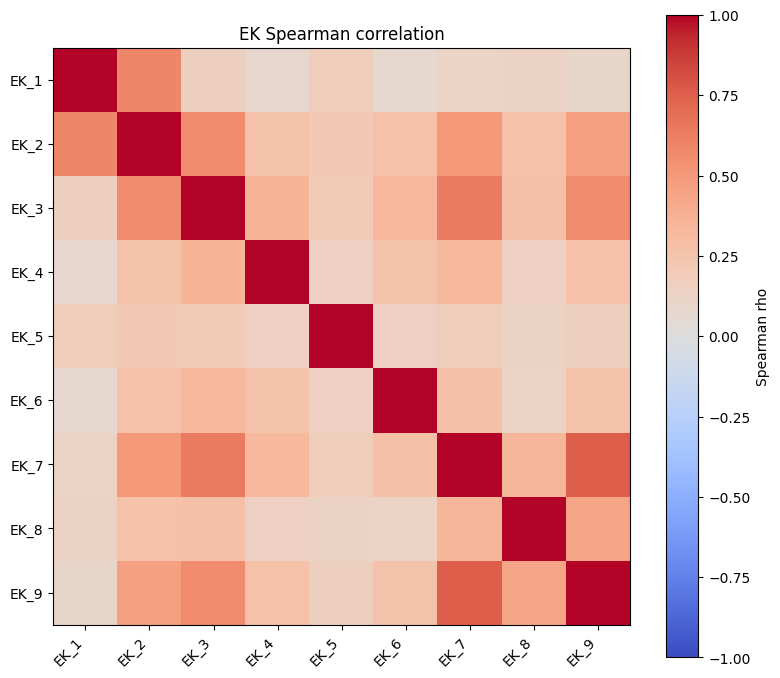

,feature_1,feature_2,spearman_rho
4,EK_7,EK_9,0.753888
2,EK_3,EK_7,0.638417
0,EK_1,EK_2,0.583466
3,EK_3,EK_9,0.569274
1,EK_2,EK_3,0.567391


In [9]:
ek_summary = master[ek_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
ek_summary["missing_rate"] = master[ek_cols].isna().mean()
ek_summary["has_negative"] = (master[ek_cols] < 0).any()
ek_summary.to_csv(TABLE_DIR / "phase2_ek_summary.csv")
display(ek_summary)

ek_corr = master[ek_cols].corr(method="spearman")
ek_corr.to_csv(TABLE_DIR / "phase2_ek_spearman_correlation.csv")

plt.figure(figsize=(8, 7))
plt.imshow(ek_corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Spearman rho")
plt.xticks(range(len(ek_cols)), ek_cols, rotation=45, ha="right")
plt.yticks(range(len(ek_cols)), ek_cols)
plt.title("EK Spearman correlation")
plt.tight_layout()
plt.savefig(FIG_DIR / "ek_spearman_correlation.png", dpi=170)
plt.show()

ek_pairs = []
for i, c1 in enumerate(ek_cols):
    for c2 in ek_cols[i+1:]:
        rho = ek_corr.loc[c1, c2]
        if abs(rho) > 0.5:
            ek_pairs.append({"feature_1": c1, "feature_2": c2, "spearman_rho": rho})
pd.DataFrame(ek_pairs).sort_values("spearman_rho", ascending=False)


In [10]:
aa_frequency = []
for col in aa_cols:
    for value, count in master[col].fillna("missing").value_counts().items():
        aa_frequency.append({"column": col, "value": value, "count": int(count)})
aa_frequency = pd.DataFrame(aa_frequency)
aa_frequency.to_csv(TABLE_DIR / "phase2_aa_frequency.csv", index=False)

aa_pair = master["AA_1"].astype(str) + ">" + master["AA_2"].astype(str)
aa_pairs = aa_pair.value_counts().reset_index()
aa_pairs.columns = ["aa_pair", "count"]
aa_pairs.to_csv(TABLE_DIR / "phase2_aa_pairs.csv", index=False)

standard_aas = set("ACDEFGHIKLMNPQRSTVWY")
nonstandard = sorted((set(master["AA_1"].dropna().astype(str)) | set(master["AA_2"].dropna().astype(str))) - standard_aas)

display(aa_frequency.head(30))
display(aa_pairs.head(25))
print("Non-standard AA codes:", nonstandard)


,column,value,count
0,AA_1,R,422
1,AA_1,missing,348
2,AA_1,G,243
3,AA_1,L,184
4,AA_1,D,165
5,AA_1,P,160
6,AA_1,C,150
7,AA_1,A,142
8,AA_1,V,135
9,AA_1,E,125


,aa_pair,count
0,G>R,84
1,R>C,80
2,L>P,75
3,E>K,75
4,R>H,74
5,R>Q,73
6,P>L,71
7,R>W,68
8,C>Y,54
9,D>N,47


Non-standard AA codes: ['*', 'AG', 'AS', 'CG', 'PN', 'RI', 'SD', 'SV', 'TH']


## Phase 3 - Bivariate Analysis: Features vs Label


In [11]:
aggregate = pd.DataFrame(index=master.index)
al_raw = [f"AL_{i}" for i in range(1, 27)]
aggregate["n_pops"] = master[al_raw].notna().sum(axis=1)
aggregate["n_nonmiss_AL"] = master[al_cols].notna().sum(axis=1)
aggregate["max_AF"] = master[al_raw].max(axis=1).fillna(0.0)
aggregate["min_AF_nz"] = master[al_raw].replace(0, np.nan).min(axis=1)
aggregate["EK7xEK9"] = master["EK_7"] * master["EK_9"]
aggregate["EK7_minus_EK9"] = master["EK_7"] - master["EK_9"]

numeric_for_auc = pd.concat([master[al_cols + ek_cols], aggregate], axis=1)

auc_rows = []
for feature in numeric_for_auc.columns:
    auc, pvalue, effect = auc_equivalent(numeric_for_auc[feature], master["Label"])
    auc_rows.append({
        "feature": feature,
        "auc_equivalent": auc,
        "auc_directional_strength": abs(auc - 0.5) + 0.5 if pd.notna(auc) else np.nan,
        "p_value": pvalue,
        "rank_biserial": effect,
        "n_notna": int(numeric_for_auc[feature].notna().sum()),
    })

auc_df = pd.DataFrame(auc_rows).sort_values("auc_directional_strength", ascending=False)
auc_df.to_csv(TABLE_DIR / "phase3_numeric_auc_ranked.csv", index=False)
display(auc_df.head(25))
display(auc_df.sort_values("auc_directional_strength").head(25))


,feature,auc_equivalent,auc_directional_strength,p_value,rank_biserial,n_notna
340,EK_7,0.738042,0.738042,5.720008e-73,0.476084,2572
347,EK7xEK9,0.726059,0.726059,3.577778e-60,0.452118,2324
342,EK_9,0.695513,0.695513,1.779816e-45,0.391025,2324
336,EK_3,0.690208,0.690208,3.452898e-33,0.380417,1601
343,n_pops,0.316095,0.683905,2.957491e-57,-0.367810,2931
335,EK_2,0.673770,0.673770,1.012204e-39,0.347539,2572
344,n_nonmiss_AL,0.336843,0.663157,2.733690e-42,-0.326314,2931
286,AL_287,0.342764,0.657236,5.309885e-17,-0.314472,979
214,AL_215,0.351670,0.648330,2.058246e-12,-0.296660,752
25,AL_26,0.355282,0.644718,9.567513e-24,-0.289436,1846


,feature,auc_equivalent,auc_directional_strength,p_value,rank_biserial,n_notna
311,AL_312,0.5,0.5,1.0,0.0,1632
308,AL_309,0.5,0.5,1.0,0.0,1632
283,AL_284,0.5,0.5,1.0,0.0,1041
271,AL_272,0.5,0.5,1.0,0.0,1041
275,AL_276,0.5,0.5,1.0,0.0,1041
279,AL_280,0.5,0.5,1.0,0.0,1041
306,AL_307,0.5,0.5,1.0,0.0,1632
121,AL_122,0.5,0.5,1.0,0.0,1486
124,AL_125,0.5,0.5,1.0,0.0,1486
130,AL_131,0.5,0.5,1.0,0.0,1486


In [12]:
miss_signal_rows = []
for col in master.columns:
    rate = master[col].isna().mean()
    if 0 < rate < 1:
        miss = master[col].isna().astype(float)
        miss_signal_rows.append({
            "column": col,
            "missing_rate": rate,
            "label_rate_when_missing": float(master.loc[master[col].isna(), "Label"].mean()),
            "label_rate_when_present": float(master.loc[master[col].notna(), "Label"].mean()),
            "missing_label_corr": float(miss.corr(master["Label"])),
        })

miss_signal_df = pd.DataFrame(miss_signal_rows).sort_values(
    "missing_label_corr", key=lambda s: s.abs(), ascending=False
)
miss_signal_df.to_csv(TABLE_DIR / "phase3_missingness_as_feature.csv", index=False)
miss_signal_df.head(25)


,column,missing_rate,label_rate_when_missing,label_rate_when_present,missing_label_corr
3,AL_4,0.899693,0.784224,0.275510,0.345526
2,AL_3,0.899693,0.784224,0.275510,0.345526
0,AL_1,0.899693,0.784224,0.275510,0.345526
1,AL_2,0.899693,0.784224,0.275510,0.345526
5,AL_6,0.899693,0.784224,0.275510,0.345526
4,AL_5,0.899693,0.784224,0.275510,0.345526
29,AL_29,0.914023,0.775289,0.285714,0.310302
30,AL_30,0.914023,0.775289,0.285714,0.310302
32,AL_32,0.914023,0.775289,0.285714,0.310302
37,AL_37,0.914023,0.775289,0.285714,0.310302


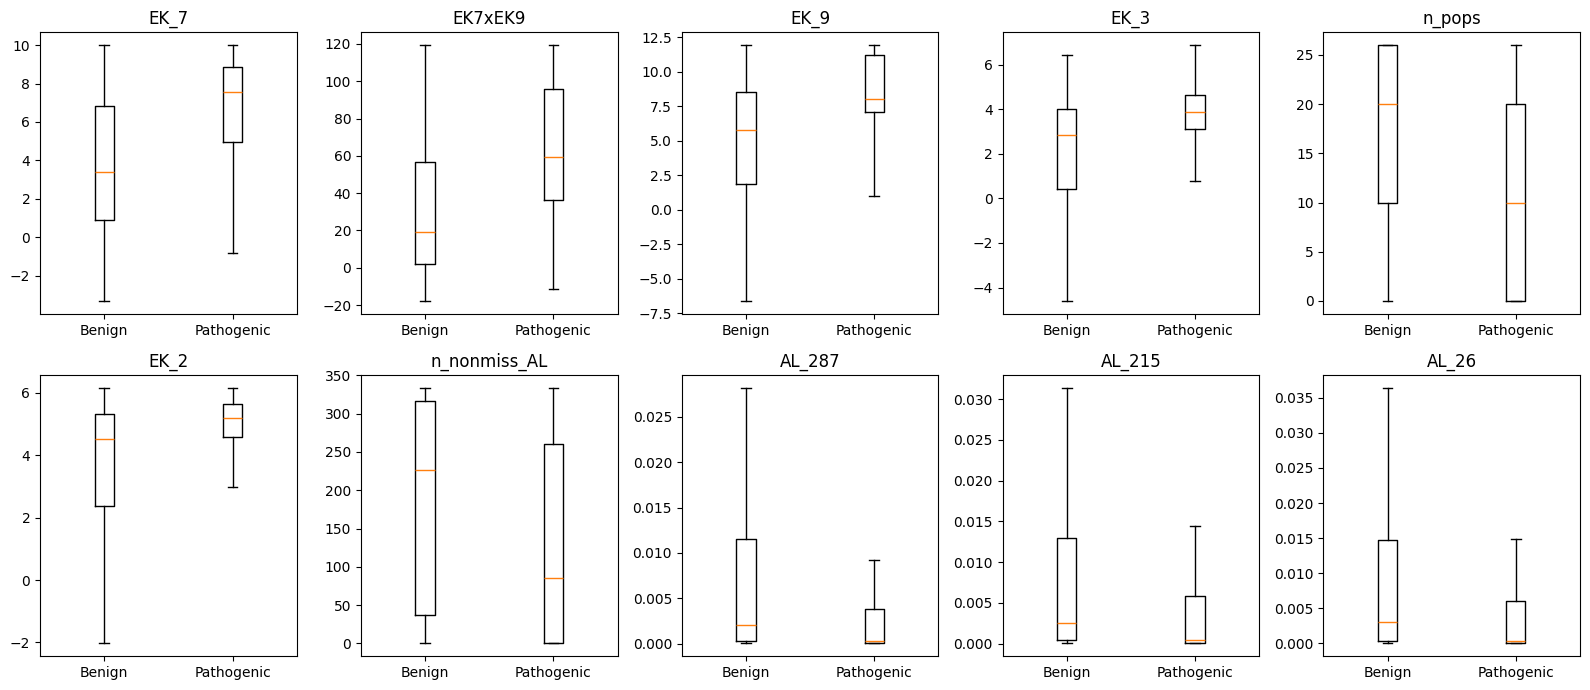

In [13]:
top10 = auc_df["feature"].head(10).tolist()
plot_df = master.join(aggregate)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, feature in zip(axes.ravel(), top10):
    data_to_plot = [
        pd.to_numeric(plot_df.loc[plot_df["Label"] == label, feature], errors="coerce").dropna()
        for label in [0, 1]
    ]
    ax.boxplot(data_to_plot, labels=["Benign", "Pathogenic"], showfliers=False)
    ax.set_title(feature)
plt.tight_layout()
plt.savefig(FIG_DIR / "top10_numeric_boxplots.png", dpi=170)
plt.show()


## Phase 4 - Multivariate And Structural Analysis


In [14]:
triplet_rows = []
for start in range(27, 334, 3):
    triple = [f"AL_{i}" for i in range(start, min(start + 3, 335)) if f"AL_{i}" in master.columns]
    if len(triple) == 3:
        corr = master[triple].corr(method="spearman")
        vals = [corr.iloc[0, 1], corr.iloc[0, 2], corr.iloc[1, 2]]
        mean_abs_rho = np.nan if pd.isna(vals).all() else float(np.nanmean(np.abs(vals)))
        triplet_rows.append({
            "columns": ",".join(triple),
            "rho_12": vals[0],
            "rho_13": vals[1],
            "rho_23": vals[2],
            "mean_abs_rho": mean_abs_rho,
        })

triplet_df = pd.DataFrame(triplet_rows)
triplet_df.to_csv(TABLE_DIR / "phase4_al_triplet_correlations.csv", index=False)
display(triplet_df.sort_values("mean_abs_rho").head(15))
display(triplet_df.sort_values("mean_abs_rho", ascending=False).head(15))


,columns,rho_12,rho_13,rho_23,mean_abs_rho
73,"AL_246,AL_247,AL_248",-0.004616,NaN,NaN,0.004616
29,"AL_114,AL_115,AL_116",-0.005175,NaN,NaN,0.005175
76,"AL_255,AL_256,AL_257",NaN,-0.005760,NaN,0.005760
7,"AL_48,AL_49,AL_50",0.012210,-0.000520,0.005611,0.006114
26,"AL_105,AL_106,AL_107",0.007374,NaN,NaN,0.007374
83,"AL_276,AL_277,AL_278",NaN,NaN,-0.007692,0.007692
79,"AL_264,AL_265,AL_266",-0.021498,-0.002098,-0.001684,0.008427
30,"AL_117,AL_118,AL_119",0.010109,NaN,NaN,0.010109
37,"AL_138,AL_139,AL_140",0.010720,NaN,NaN,0.010720
8,"AL_51,AL_52,AL_53",0.011573,0.000646,0.021862,0.011360


,columns,rho_12,rho_13,rho_23,mean_abs_rho
80,"AL_267,AL_268,AL_269",-0.029795,1.000000,-0.029795,0.353197
0,"AL_27,AL_28,AL_29",0.268911,0.065811,0.248208,0.194310
3,"AL_36,AL_37,AL_38",0.120672,0.184690,0.212295,0.172553
90,"AL_297,AL_298,AL_299",0.121246,NaN,NaN,0.121246
53,"AL_186,AL_187,AL_188",0.085856,0.228541,0.034803,0.116400
1,"AL_30,AL_31,AL_32",0.137067,0.067429,0.141929,0.115475
2,"AL_33,AL_34,AL_35",0.152766,0.044396,0.101536,0.099566
21,"AL_90,AL_91,AL_92",0.076422,0.052649,0.153690,0.094254
31,"AL_120,AL_121,AL_122",0.094109,NaN,NaN,0.094109
48,"AL_171,AL_172,AL_173",0.091057,NaN,NaN,0.091057


In [15]:
cross = master[ek_cols].join(aggregate).corr(method="spearman")
cross.to_csv(TABLE_DIR / "phase4_cross_group_spearman.csv")

high_cross = []
for c1 in ek_cols:
    for c2 in aggregate.columns:
        rho = cross.loc[c1, c2]
        if pd.notna(rho) and abs(rho) > 0.5:
            high_cross.append({"feature_1": c1, "feature_2": c2, "spearman_rho": rho})

high_cross_df = pd.DataFrame(high_cross)
high_cross_df.to_csv(TABLE_DIR / "phase4_high_cross_group_correlations.csv", index=False)
high_cross_df


,feature_1,feature_2,spearman_rho
0,EK_3,EK7xEK9,0.614823
1,EK_7,EK7xEK9,0.952182
2,EK_9,EK7xEK9,0.893963
3,EK_9,EK7_minus_EK9,-0.558858


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.307286,0.307286
1,PC2,0.106777,0.414063
2,PC3,0.024255,0.438318
3,PC4,0.024004,0.462322
4,PC5,0.022910,0.485232
5,PC6,0.018524,0.503756
6,PC7,0.012222,0.515979
7,PC8,0.009696,0.525675
8,PC9,0.009481,0.535156
9,PC10,0.008872,0.544027


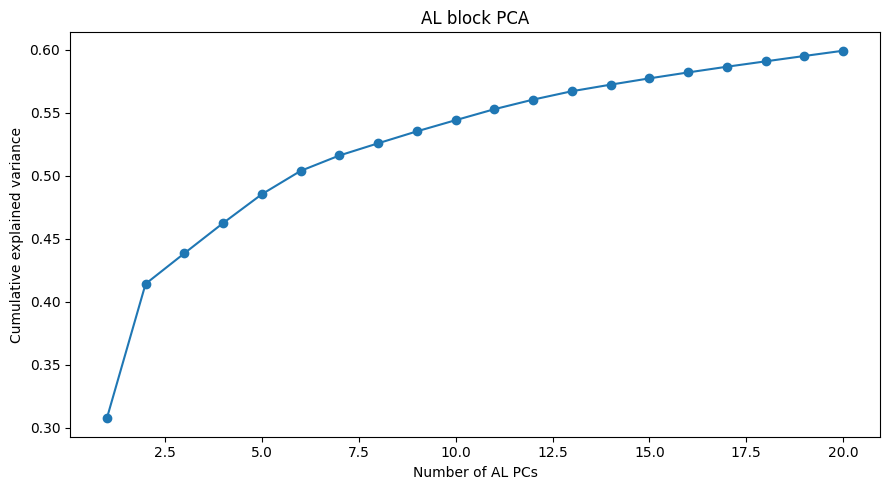

In [16]:
x_al = master[al_cols].apply(pd.to_numeric, errors="coerce")
x_al = SimpleImputer(strategy="median").fit_transform(x_al)
x_al = StandardScaler().fit_transform(x_al)

pca = PCA(n_components=20, random_state=42)
pca.fit(x_al)
pca_df = pd.DataFrame({
    "component": [f"PC{i}" for i in range(1, 21)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
})
pca_df.to_csv(TABLE_DIR / "phase4_al_pca.csv", index=False)
display(pca_df)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 21), pca_df["cumulative_explained_variance"], marker="o")
plt.xlabel("Number of AL PCs")
plt.ylabel("Cumulative explained variance")
plt.title("AL block PCA")
plt.tight_layout()
plt.savefig(FIG_DIR / "al_pca_cumulative_variance.png", dpi=170)
plt.show()


In [17]:
leakage_df = auc_df[auc_df["auc_directional_strength"] > 0.85]
leakage_df.to_csv(TABLE_DIR / "phase4_leakage_suspects.csv", index=False)
if leakage_df.empty:
    print("No individual feature exceeds directional AUC strength 0.85.")
else:
    display(leakage_df)


No individual feature exceeds directional AUC strength 0.85.


## Phase 5 - Cross-Dataset Comparison


In [18]:
top10_features = auc_df["feature"].head(10).tolist()
shift_rows = []

for name, df in data.items():
    agg = pd.DataFrame(index=df.index)
    agg["n_pops"] = df[al_raw].notna().sum(axis=1)
    agg["n_nonmiss_AL"] = df[al_cols].notna().sum(axis=1)
    agg["max_AF"] = df[al_raw].max(axis=1).fillna(0.0)
    agg["min_AF_nz"] = df[al_raw].replace(0, np.nan).min(axis=1)
    agg["EK7xEK9"] = df["EK_7"] * df["EK_9"]
    agg["EK7_minus_EK9"] = df["EK_7"] - df["EK_9"]
    merged = df.join(agg)
    for feature in top10_features:
        if feature in merged.columns:
            shift_rows.append({
                "dataset": name,
                "feature": feature,
                "mean": float(pd.to_numeric(merged[feature], errors="coerce").mean()),
                "median": float(pd.to_numeric(merged[feature], errors="coerce").median()),
                "pathogenic_mean": float(pd.to_numeric(merged.loc[merged["Label"] == 1, feature], errors="coerce").mean()),
                "benign_mean": float(pd.to_numeric(merged.loc[merged["Label"] == 0, feature], errors="coerce").mean()),
                "missing_rate": float(merged[feature].isna().mean()),
            })

shift_df = pd.DataFrame(shift_rows)
shift_df.to_csv(TABLE_DIR / "phase5_top10_cross_dataset_shift.csv", index=False)
shift_df.head(40)


,dataset,feature,mean,median,pathogenic_mean,benign_mean,missing_rate
0,MASTER,EK_7,5.944229,7.100062,6.636712,3.849441,0.122484
1,MASTER,EK7xEK9,54.201344,55.089942,61.385104,32.748639,0.207097
2,MASTER,EK_9,7.482126,7.853836,8.209316,5.310535,0.207097
3,MASTER,EK_3,3.046202,3.691725,3.524241,1.895857,0.453770
4,MASTER,n_pops,10.320027,10.000000,8.632852,14.956522,0.000000
5,MASTER,EK_2,4.464253,5.098377,4.851009,3.294302,0.122484
6,MASTER,n_nonmiss_AL,144.113954,125.000000,126.291298,193.092072,0.000000
7,MASTER,AL_287,0.014687,0.000745,0.010963,0.020033,0.665984
8,MASTER,AL_215,0.017661,0.000985,0.013673,0.022098,0.743432
9,MASTER,AL_26,0.014779,0.000870,0.010200,0.024504,0.370181


In [19]:
panel_unique_rows = []
numeric_cols = al_cols + ek_cols

for name in panel_names:
    df = data[name]
    unique = df[~df["Variant_ID"].isin(master_ids)]
    shared = df[df["Variant_ID"].isin(master_ids)]
    for subset_name, subset in [("unique", unique), ("shared_with_master", shared)]:
        panel_unique_rows.append({
            "panel": name,
            "subset": subset_name,
            "n": len(subset),
            "pathogenic_rate": float(subset["Label"].mean()),
            "overall_missing_rate": float(subset.isna().mean().mean()),
            "numeric_range_mean": float(
                subset[numeric_cols].apply(
                    lambda s: pd.to_numeric(s, errors="coerce").max() - pd.to_numeric(s, errors="coerce").min()
                ).mean()
            ),
        })

panel_unique_df = pd.DataFrame(panel_unique_rows)
panel_unique_df.to_csv(TABLE_DIR / "phase5_panel_unique_vs_shared.csv", index=False)
panel_unique_df


,panel,subset,n,pathogenic_rate,overall_missing_rate,numeric_range_mean
0,KANSER,unique,142,0.316901,0.427742,0.647921
1,KANSER,shared_with_master,246,0.906504,0.654875,0.828301
2,PAH,unique,117,0.581197,0.576814,0.487153
3,PAH,shared_with_master,255,0.949020,0.527445,0.531461
4,CFTR,unique,34,0.500000,0.224546,0.552333
5,CFTR,shared_with_master,77,0.948052,0.337331,0.554045


### Panel Summary

KANSER unique subset has a much lower pathogenic rate than KANSER variants shared
with MASTER, indicating a major distribution shift. PAH and CFTR unique subsets
are smaller, but also differ strongly from shared subsets. This supports treating
panel-unique variants as a harder generalization check.


## Phase 6 - ACMG Evidence Interpretation


In [20]:
acmg_rows = []
for _, row in auc_df.head(25).iterrows():
    f = row["feature"]
    if f in ["max_AF", "AL_26"] or f.startswith("AL_"):
        criterion = "BA1/BS1/PM2"
        meaning = "Population frequency or rarity evidence; direction must be interpreted from AUC and distributions."
        confidence = "medium"
    elif f in ["n_pops", "n_nonmiss_AL"]:
        criterion = "PM2/BS2 proxy"
        meaning = "Database absence/presence aggregate; missingness encodes rarity and ascertainment."
        confidence = "high"
    elif f.startswith("EK_") or f.startswith("EK7"):
        criterion = "PP3/BP4"
        meaning = "Computational/evolutionary pathogenicity evidence."
        confidence = "medium"
    elif f.startswith("AA") or f.startswith("aa"):
        criterion = "PM5/PP3 proxy"
        meaning = "Amino-acid substitution chemistry or learned substitution prior."
        confidence = "low"
    else:
        criterion = "technical/statistical artifact candidate"
        meaning = "Predictive behavior does not cleanly map to a single ACMG criterion."
        confidence = "low"
    acmg_rows.append({
        "feature": f,
        "auc_equivalent": row["auc_equivalent"],
        "proposed_acmg_category": criterion,
        "justification": meaning,
        "confidence": confidence,
    })

acmg_df = pd.DataFrame(acmg_rows)
acmg_df.to_csv(TABLE_DIR / "phase6_acmg_interpretation.csv", index=False)
acmg_df


,feature,auc_equivalent,proposed_acmg_category,justification,confidence
0,EK_7,0.738042,PP3/BP4,Computational/evolutionary pathogenicity evide...,medium
1,EK7xEK9,0.726059,PP3/BP4,Computational/evolutionary pathogenicity evide...,medium
2,EK_9,0.695513,PP3/BP4,Computational/evolutionary pathogenicity evide...,medium
3,EK_3,0.690208,PP3/BP4,Computational/evolutionary pathogenicity evide...,medium
4,n_pops,0.316095,PM2/BS2 proxy,Database absence/presence aggregate; missingne...,high
5,EK_2,0.673770,PP3/BP4,Computational/evolutionary pathogenicity evide...,medium
6,n_nonmiss_AL,0.336843,PM2/BS2 proxy,Database absence/presence aggregate; missingne...,high
7,AL_287,0.342764,BA1/BS1/PM2,Population frequency or rarity evidence; direc...,medium
8,AL_215,0.351670,BA1/BS1/PM2,Population frequency or rarity evidence; direc...,medium
9,AL_26,0.355282,BA1/BS1/PM2,Population frequency or rarity evidence; direc...,medium


## Output Files

All notebook-generated tables are written to `reports/eda_notebook_outputs/tables`.
All notebook-generated figures are written to `reports/eda_notebook_outputs/figures`.
